In [2]:
# %matplotlib widget
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from quspin.operators import hamiltonian
from DSF import *

In [51]:
M, N = 2, 2
J_nnn, dmi, h = 0.1, 0.j, 0.1
# beta = [0.01, 0.1, 1, 1.3, 2, 3, 4, 5, 6, 10]
beta = [10]
w = np.linspace(0.0, 6.0, 601)
T = np.linspace(0, 10, 101)

basis, r = build_HC_basis(M, N)
H = H_HC(M, N, 1, 1, J_nnn, dmi, h, basis)

# b1, b2 = [2/3, 0], [1/3, 1/(3**0.5)]
b1, b2 = [1/(3**0.5), -1/3], [0, 2/3]
n1, n2 = 1, 1
Q = np.zeros(2)
Q[0] = 2*np.pi * (b1[0]*n1/N + b2[0]*n2/M)
Q[1] = 2*np.pi * (b1[1]*n1/N + b2[1]*n2/M)

S1_list, S2_list = [], []
for i in range(N*M*2):
    # S2_list.append([0, i])
    S1_list.append([1/(N*M*2)**0.5 * np.exp(1j*(Q[0]*r[i][0] + Q[1]*r[i][1])), i])
    S2_list.append([1/(N*M)**0.5 * np.exp(-1j*(Q[0]*r[i][0] + Q[1]*r[i][1])), i])
    # M
    # S1_list.append([0, i])
    # S2_list.append([1/(N*M*2), i])
# Sa, Sb = 0, 0
# S2_list[Sa][0] = 0.5*np.exp(-1j*(Q[0]*r[Sa][0] + Q[1]*r[Sa][1]))
# S2_list[Sb][0] = 0.5*np.exp(-1j*(Q[0]*r[Sb][0] + Q[1]*r[Sb][1]))
# S1_list[Sa][0] = 1
# S2_list[Sb][0] = 1

Sx1 = hamiltonian([["x", S1_list]], [], basis=basis, dtype=np.complex128, check_herm = False)
Sx2 = hamiltonian([["x", S2_list]], [], basis=basis, dtype=np.complex128, check_herm = False)
  
Sy1 = hamiltonian([["y", S1_list]], [], basis=basis, dtype=np.complex128, check_herm = False)
Sy2 = hamiltonian([["y", S2_list]], [], basis=basis, dtype=np.complex128, check_herm = False)
  
Sz1 = hamiltonian([["z", S1_list]], [], basis=basis, dtype=np.complex128, check_herm = False)
Sz2 = hamiltonian([["z", S2_list]], [], basis=basis, dtype=np.complex128, check_herm = False)

Sp1 = hamiltonian([["+", S1_list]], [], basis=basis, dtype=np.complex128, check_herm = False)
Sm2 = hamiltonian([["-", S2_list]], [], basis=basis, dtype=np.complex128, check_herm = False)

# E_0, V_0, Szz_full, Z_full, Szz_full_T0, Mz = dsf_exact(Sz1, Sz2, H, w, beta)
# E_0, V_0, Sxx_full, Z_full, Sxx_full_T0, Mx = dsf_xt_exact(Sx1, Sx2, H, T, beta)
# E_0, V_0, Syy_full, Z_full, Syy_full_T0, My = dsf_xt_exact(Sy1, Sy2, H, T, beta)
# E_0, V_0, Szz_full, Z_full, Szz_full_T0, Mz = dsf_xt_exact(Sz1, Sz2, H, T, beta)
E_0, V_0, Spm_full, Zpm_full, Spm_full_T0, Mz = dsf_exact(Sp1, Sm2, H, w, beta)
# E_0, V_0, Spm_full, Zpm_full, Spm_full_T0, Mz = dsf_xt_exact(Sp1, Sm2, H, T, beta)

constructed hexagonal lattice with 8 sites.

Hilbert space size: 256.

Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
E0 = -3.9999999999999973
Peak memory used for exact solution w=0.0:306.9297 MB
Peak memory used for exact solution w=0.0:306.9297 MB
Peak memory used for exact solution w=0.0:306.9297 MB
Peak memory used for exact solution w=0.0:306.9297 MB
Peak memory used for exact solution w=0.0:306.9297 MB
Peak memory used for exact solution w=0.1:306.9297 MB
Peak memory used for exact solution w=0.1:306.9297 MB
Peak memory used for exact solution w=0.1:306.9297 MB
Peak memory used for exact solution w=0.1:306.9297 MB
Peak memory used for exact solution w=0.1:306.9297 MB
Peak memory used for exact solution w=0.1:306.9297 MB
Peak memory used for exact solution w=0.1:306.9297 MB
Peak memory used for exact solution w=0.

### test

In [8]:
data = pd.DataFrame({
    "beta": beta,
    "Sz": np.real(M/Z_full),
})
data.to_csv("./HC_data/ED_22.csv")

In [7]:
M/Z_full

array([-2.52260493e-04+0.j, -2.73559285e-03+0.j, -5.53544626e-02+0.j,
       -8.27115291e-02+0.j, -1.46778957e-01+0.j, -2.20690797e-01+0.j,
       -2.76680066e-01+0.j, -3.19766537e-01+0.j, -3.53014767e-01+0.j,
       -4.27391651e-01+0.j])

In [3]:

file2 = sorted(glob.glob("./HC_data/Chi_22_DM0.10_S1S1_beta0.10_db0.01_psi-*_tau-*_Time*_dt0.05_xx_2+2.csv"))
file2

['./HC_data/Chi_22_DM0.10_S1S1_beta0.10_db0.01_psi-10_tau-10_Time10_dt0.05_xx_2+2.csv',
 './HC_data/Chi_22_DM0.10_S1S1_beta0.10_db0.01_psi-12_tau-12_Time10_dt0.05_xx_2+2.csv']

# real space

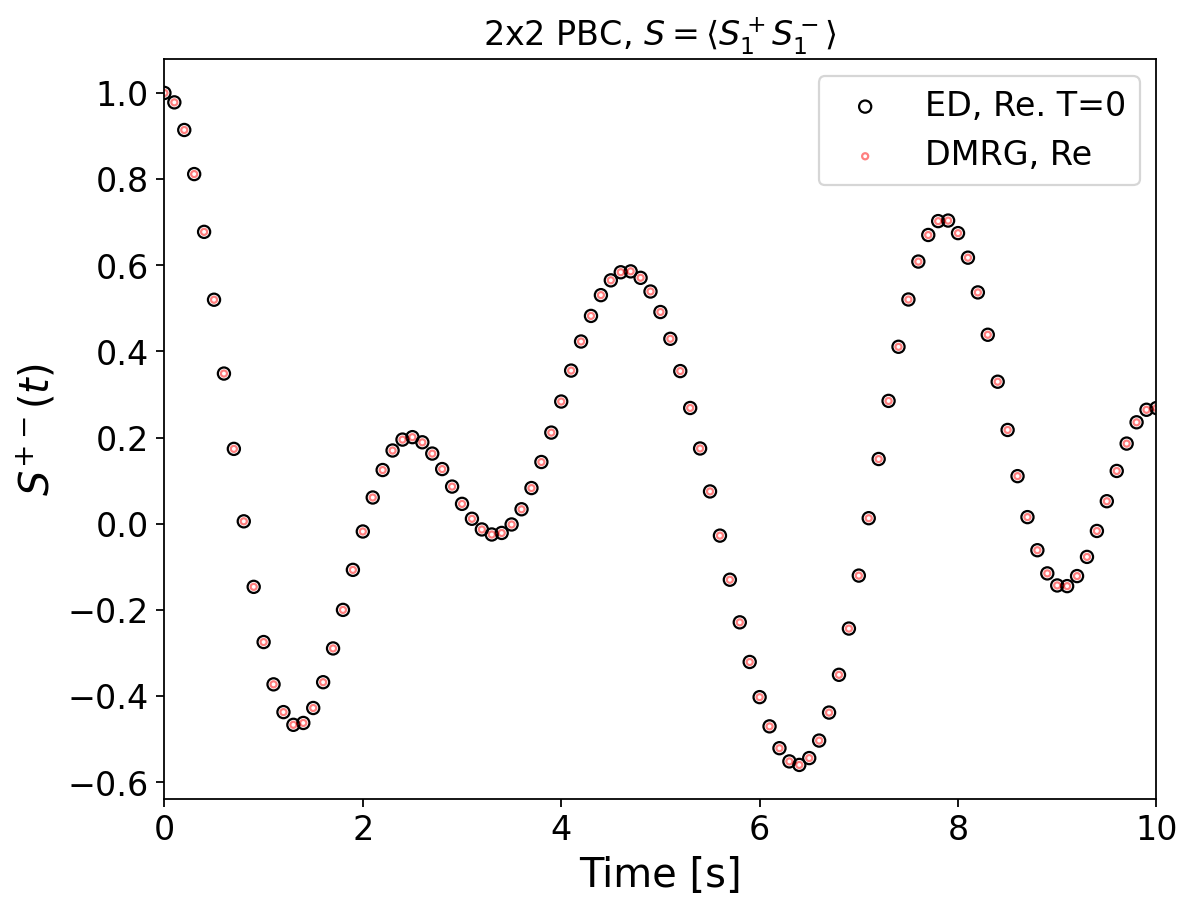

In [36]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=160)

# ax.scatter(T, np.real(Szz_full.flatten()/Z_full), 
#     s=30, marker="o", c="#CC0FD690", edgecolors='none',
#     label="ED, Re")
# ax.scatter(T, np.imag(Sxx_full.flatten()/Z_full), 
#     s=30, marker="o", c="#AAD60090", edgecolors='none',
#     label="ED, Im")
# colors = ['C1', 'C2', 'C3']
# for i in range(3):
#     ax.scatter(T, np.real(Sxx_full.T[i].flatten()/Z_full[i]), 
#         s=40-5*i, marker="o", c=colors[i], edgecolors='none',
#         label=f"ED, Re. T={1/beta[i]}")

ax.scatter(T, np.real(Spm_full_T0), 
    s=30, marker="o", c="none", edgecolors='k', zorder=0,
    label="ED, Re. T=0")
# ax.scatter(T, np.imag(Sxx_full_T0), 
#     s=20, marker="s", c="#AAD60090", edgecolors='none',
#     label="ED, Im")

dmrg = pd.read_csv("./HC_data/Chi_22_nnn0.0_DM0.00_Oxf_Oyf_S1S1_GS_psi-10_Time10_pm.csv")
# files = sorted(glob.glob("./HC_data/Chi_22_DM0.10_S1S1_beta1.00_db0.01_psi-*_tau-10_Time*_dt0.05_xx.csv"))
# labels = [-10, -11, -12]
# markers = ['s', 'p', 'h']
# colors = ['r', 'g', 'b']
# for i, fi in enumerate(files):
#     dmrg = pd.read_csv(fi)
#     ax.scatter(dmrg.t, dmrg.RS,
#         s=30, marker=markers[i], c="none", edgecolors=colors[i], alpha=0.7,
#         label=f"Re DMRG. Cut=1E{labels[i]}"
#         )
ax.scatter(dmrg.t, dmrg.RS,
    s=30, marker=".", c="none", edgecolors='r', alpha=0.5,
    label=f"DMRG, Re"
    )

# file2 = sorted(glob.glob("./HC_data/Chi_22_DM0.10_S1S1_beta0.10_db0.01_psi-*_tau-*_Time*_dt0.05_xx_2+2.csv"))
# dmrg = pd.read_csv(file2[0])
# ax.scatter(dmrg.t, dmrg.RS,
#     s=10, marker='o', c="none", edgecolors='k', alpha=0.7,
#     label=f"Re DMRG. Cut=1E-10, TDVP2"
#     )
# dmrg = pd.read_csv(file2[1])
# ax.scatter(dmrg.t, dmrg.RS,
#     s=10, marker='o', c="none", edgecolors='r', alpha=0.7,
#     label=f"Re DMRG. TDVP2 \nCut=1E-12, Time cut=1E-12"
#     )
# ax.scatter(dmrg.t[400:], np.real(Szz_full.flatten()/Z_full)-dmrg.RS[400:],
#     s=10, marker='.', label='deviation')

ax.legend(fontsize=15)
ax.set_xlabel("Time [s]", fontsize=18)
ax.set_ylabel("$S^{+-}(t)$", fontsize=18)
ax.set_xlim(0, 10)
# ax.set_ylim(0, 0.3)
# ax.set_ylim(-0.25, 0.4)
ax.tick_params(axis='both', labelsize=15)

# ax.set_title(f"{N}x{M} PBC, $\\beta={beta[0]}$, $S = \\langle S_1^x S_1^x \\rangle$", fontsize=15)
ax.set_title(f"{N}x{M} PBC, $S = \\langle S_1^+ S_1^- \\rangle$", fontsize=15)
plt.show()

# momentum space

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


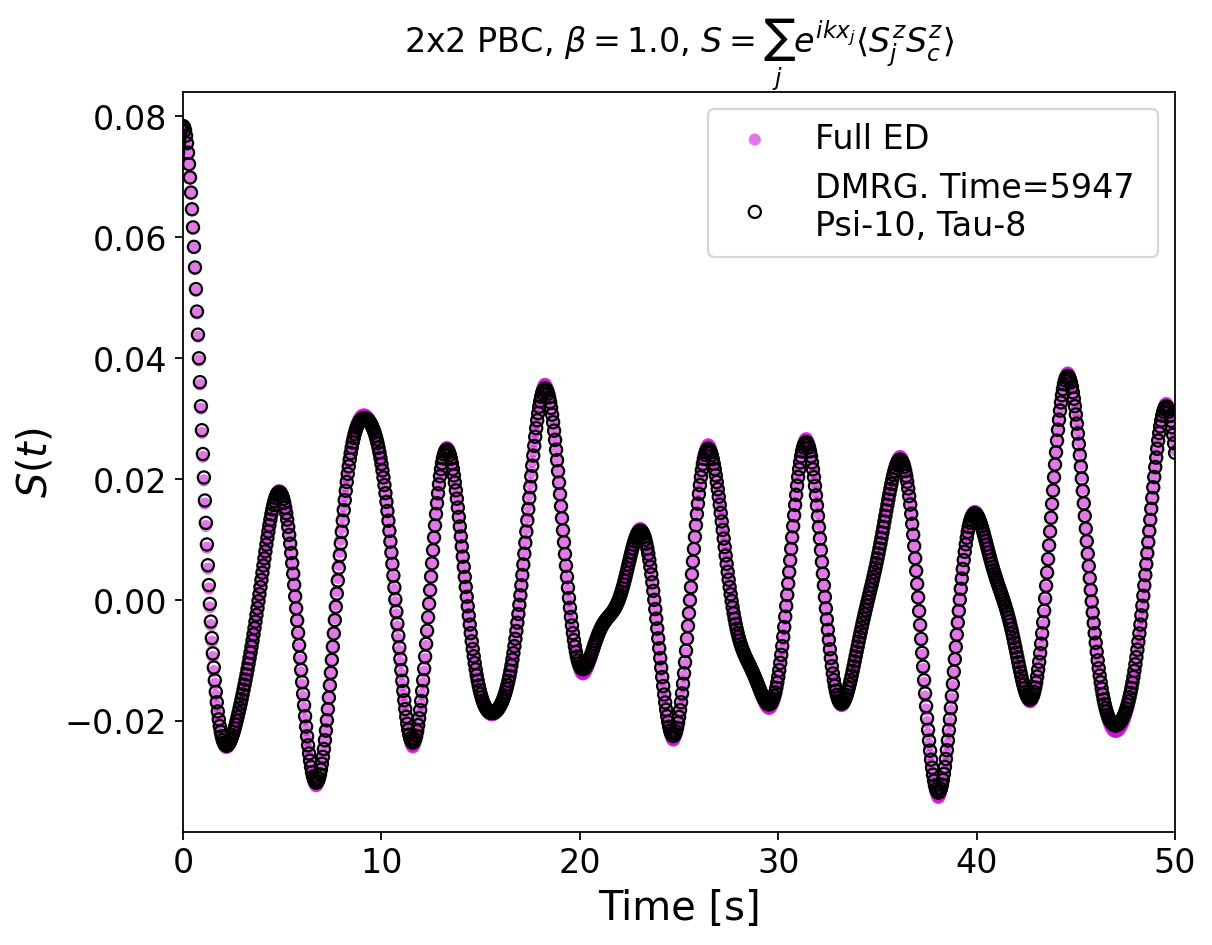

In [22]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=160)

ax.scatter(T, Szz_full.flatten()/Z_full, 
    s=30, marker="o", c="#CC0FD690", edgecolors='none',
    label="Full ED")
# ax.scatter(T, np.real(Sxx_full_T0), 
#     s=60, marker="o", c="#CC0FD690", edgecolors='none',
#     label="Re Sxx")
# ax.scatter(T, np.imag(Sxx_full_T0), 
#     s=20, marker="s", c="#AAD60090", edgecolors='none',
#     label="Im Sxx")
dmrg = pd.read_csv("./HC_data/Chi_22_DM0.10_Q11_beta1.00_db0.01_psi-10_tau-8_Time50_dt0.05_zz.csv")
ax.scatter(dmrg.t, dmrg.RS,
    s=30, marker="o", c="none", edgecolors='k', alpha=1,
    label=f"DMRG. Time=5947 \nPsi-10, Tau-8"
    )
# ax.scatter(dmrg.t, dmrg.IS,
#     s=30, marker="s", c="none", edgecolors='grey', alpha=0.5,
#     label=f"DMRG, Im"
#     )

ax.legend(fontsize=15)
ax.set_xlabel("Time [s]", fontsize=18)
ax.set_ylabel("$S(t)$", fontsize=18)
ax.set_xlim(0, 50)
ax.tick_params(axis='both', labelsize=15)

ax.set_title(f"{N}x{M} PBC, $\\beta={beta[0]}$, $S=\\sum_j e^{{ikx_j}}\\langle S_j^z S_c^z \\rangle$", fontsize=15)
# ax.set_title(f"{N}x{M} PBC, GS, $S=e^{{ikx_j}}\\langle S_j S_A \\rangle$", fontsize=15)
plt.show()

# DSF

In [52]:
dmrg = pd.read_csv(
    "./HC_data/Chi_22_nnn0.0_DM0.00_Oxf_Oyf_Q11_GS_psi-10_Time30_+-.csv")

chi_re = list(dmrg.RS)
chi_im = list(dmrg.IS)
Time = list(dmrg.t)
# w = np.linspace(0, 6, 601)

dt = Time[1]-Time[0]
sqT = 1/np.sqrt(2*Time[-1])
S = []
for idx, omega in enumerate(w):
    int_sum = 0
    for i in range(len(Time)):
        # int_sum += sqT * np.exp(1j * omega * Time[i]) * chi[i]
        int_sum += sqT * 2*np.cos(omega * Time[i]) * chi_re[i]
        int_sum -= sqT * 2*np.sin(omega * Time[i]) * chi_im[i]
    S.append(np.real(int_sum*dt))
T = Time[-1]

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


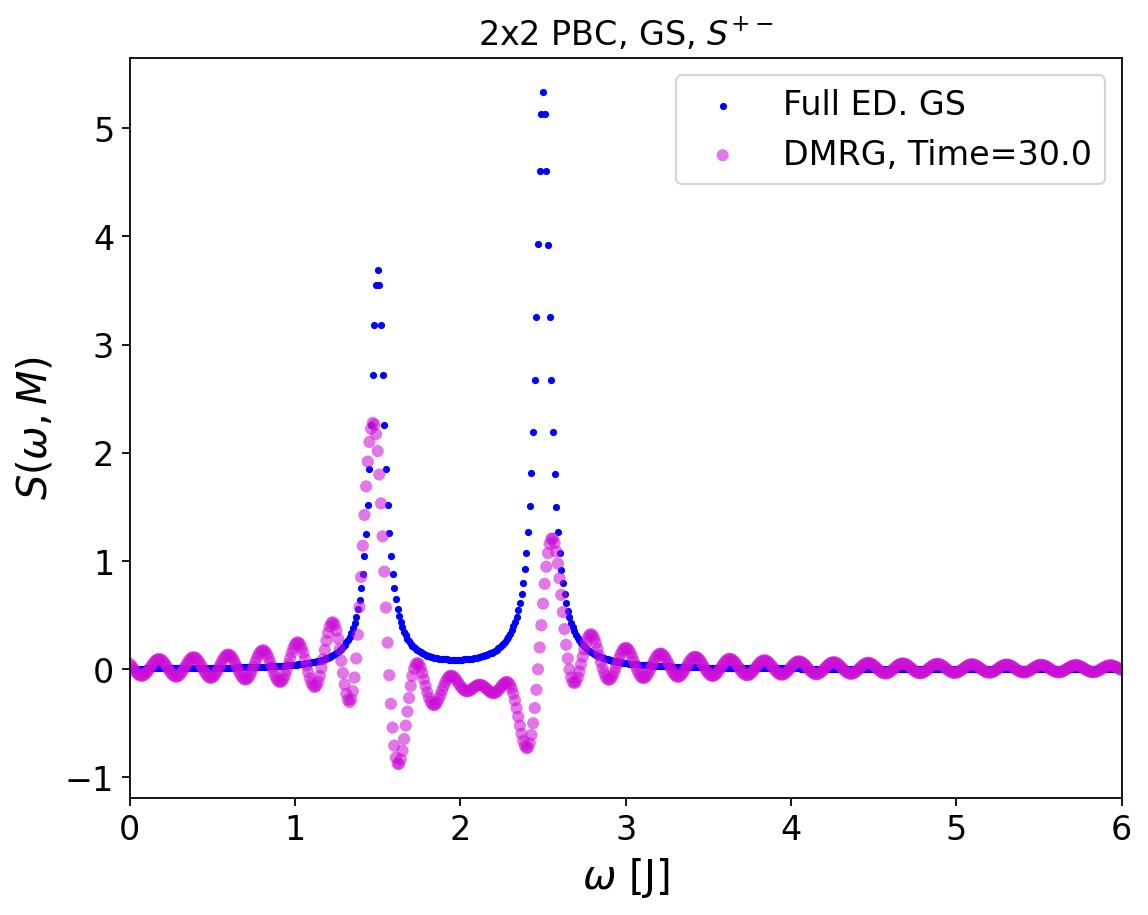

In [53]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=160)

# ax.scatter(w, Spm_full.flatten()/Z_full, 
#     s=20, marker=".", c="k", label="Full ED")
ax.scatter(w, Spm_full_T0, 
    s=20, marker=".", c="b", label="Full ED. GS")

ax.scatter(w, S,
    s=30, marker="o", c="#CC0FD690", edgecolors='none',
    label=f"DMRG, Time={T}"
    )

ax.legend(fontsize=15)
ax.set_xlabel("$\\omega$ [J]", fontsize=18)
ax.set_ylabel("$S(\\omega, M)$", fontsize=18)
ax.set_xlim(0, 6)
# ax.set_ylim(-0.025, 0.15)
ax.tick_params(axis='both', labelsize=15)

# temp = round(1/beta[0], 3)
# ax.set_title(f"{N}x{M} PBC, $T={temp}$, $S=\\sum_j e^{{i\\omega t - ikx_j}}\\langle S_j^z(t) S_c^z \\rangle$", fontsize=15)
ax.set_title(f"{N}x{M} PBC, GS, $S^{{+-}}$", fontsize=15)
plt.show()